# SigLIP vs SigLIP2 — Experimentos y Benchmark

Este notebook compara el modelo original **SigLIP** (`google/siglip-base-patch16-224`) usado en el nodo ROS con **SigLIP2** (`google/siglip2-base-patch16-224`).

Secciones:
1. Configuración y carga de modelos
2. Funciones auxiliares de embeddings
3. Matching semántico — etiquetas relevantes para navegación
4. Precisión de clasificación zero-shot
5. Coherencia semántica texto–texto
6. Benchmark — latencia y rendimiento
7. Tabla resumen
8. Espacio de embeddings — visualización PCA
9. Imágenes reales (opcional)

## 1. Configuración

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModel

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/junior/visual_semantic_navigation/.venv-1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 2060
VRAM: 6.0 GB


In [2]:
MODELS = {
    "siglip":  "google/siglip-base-patch16-224",   # modelo usado en el nodo ROS
    "siglip2": "google/siglip2-base-patch16-224",  # versión más reciente
}

processors = {}
models = {}

for name, model_id in MODELS.items():
    print(f"Loading {name} ({model_id}) …")
    processors[name] = AutoProcessor.from_pretrained(model_id)
    models[name] = AutoModel.from_pretrained(model_id).eval().to(DEVICE)
    n_params = sum(p.numel() for p in models[name].parameters()) / 1e6
    print(f"  → {n_params:.1f}M parameters\n")

print("All models loaded.")

Loading siglip (google/siglip-base-patch16-224) …


Loading weights: 100%|██████████| 408/408 [00:00<00:00, 3198.84it/s]


  → 203.2M parameters

Loading siglip2 (google/siglip2-base-patch16-224) …


Loading weights: 100%|██████████| 408/408 [00:00<00:00, 4756.72it/s]


  → 375.2M parameters

All models loaded.


## 2. Funciones auxiliares de embeddings

In [28]:
def _to_numpy(feats) -> np.ndarray:
    """Extrae el tensor del output del modelo (tensor directo o BaseModelOutputWithPooling)."""
    if hasattr(feats, "pooler_output"):
        feats = feats.pooler_output
    return feats.cpu().float().numpy()


def embed_text(model_name: str, texts: list[str]) -> np.ndarray:
    """Devuelve embeddings de texto normalizados con L2, forma (N, D).
    Usar solo para análisis de espacio de embeddings (PCA, similitud texto-texto).
    Para clasificación usar compute_logits()."""
    proc = processors[model_name]
    model = models[model_name]
    inputs = proc(text=texts, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        feats = model.get_text_features(**inputs)
    emb = _to_numpy(feats)
    return emb / (np.linalg.norm(emb, axis=-1, keepdims=True) + 1e-8)


def embed_images(model_name: str, images: list[Image.Image]) -> np.ndarray:
    """Devuelve embeddings de imagen normalizados con L2, forma (N, D).
    Usar solo para análisis de espacio de embeddings (PCA).
    Para clasificación usar compute_logits()."""
    proc = processors[model_name]
    model = models[model_name]
    inputs = proc(images=images, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        feats = model.get_image_features(**inputs)
    emb = _to_numpy(feats)
    return emb / (np.linalg.norm(emb, axis=-1, keepdims=True) + 1e-8)


def compute_logits(model_name: str, images: list[Image.Image], texts: list[str]) -> np.ndarray:
    """Devuelve logits_per_image (N_images, N_texts) usando el forward pass completo.

    A diferencia del coseno manual, aplica el logit_scale y logit_bias aprendidos
    del modelo. En SigLIP/SigLIP2 el bias es crítico: sin él el argmax está sesgado
    hacia los queries con mayor norma en el espacio de embedding.
    """
    proc = processors[model_name]
    model = models[model_name]
    img_inputs = proc(images=images, return_tensors="pt").to(DEVICE)
    txt_inputs = proc(text=texts, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = model(**img_inputs, **txt_inputs)
    return outputs.logits_per_image.cpu().float().numpy()


def cosine_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Matriz de similitud coseno por pares entre las filas de a y b."""
    return a @ b.T


print("Helpers definidos.")

Helpers definidos.


## 3. Matching semántico con imágenes reales

Se cargan imágenes reales de interiores desde HuggingFace. 
Si `HAS_GROUND_TRUTH = True`, la sección 4 calculará accuracy real. En caso contrario mostrará las predicciones del modelo sin comparar con etiquetas conocidas.

Imágenes cargadas: 4 (1 por categoría)


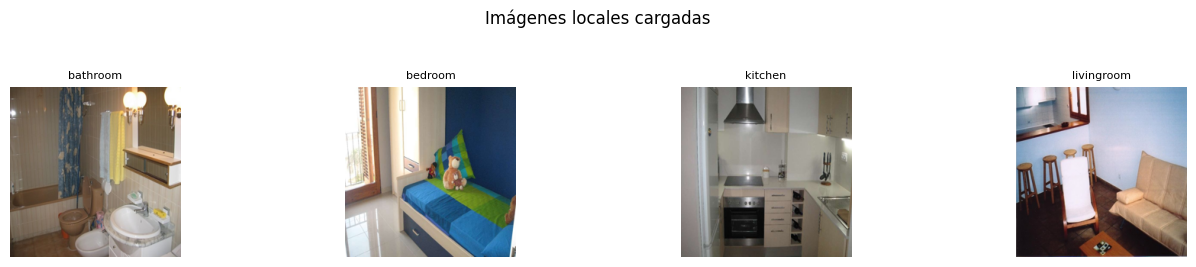

In [50]:
IMAGES_DIR = Path(__file__).parent / "images" if "__file__" in dir() else Path("images")

CATEGORY_MAP = {
    "bathroom":      "This is a photo of a bathroom.",
    "bedroom":       "This is a photo of a bedroom.",
    "kitchen":       "This is a photo of a kitchen.",
    "livingroom":    "This is a photo of a living room.",
}


scene_labels   = list(CATEGORY_MAP.keys())
text_queries   = list(CATEGORY_MAP.values())
HAS_GROUND_TRUTH = True

N_PER_LABEL = 1  # imágenes por categoría para el heatmap (aumentar para accuracy más robusta)

def make_placeholder(rgb: tuple[int, int, int], size: int = 224) -> Image.Image:
    """Imagen sintética de color sólido (usada en el benchmark de latencia)."""
    arr = np.full((size, size, 3), rgb, dtype=np.uint8)
    return Image.fromarray(arr)


def load_local_images(n: int = N_PER_LABEL) -> tuple[list[Image.Image], list[str]]:
    """Carga n imágenes por categoría desde experiments/siglip/images/."""
    images, labels = [], []
    for category in scene_labels:
        folder = IMAGES_DIR / category
        files = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
        for path in files[:n]:
            img = Image.open(path).convert("RGB").resize((224, 224))
            images.append(img)
            labels.append(category)
    return images, labels


scene_images, scene_image_labels = load_local_images()
print(f"Imágenes cargadas: {len(scene_images)} ({N_PER_LABEL} por categoría)")

# Mostrar una muestra de cada categoría
fig, axes = plt.subplots(1, len(scene_labels), figsize=(14, 2.5))
for ax, img, lbl in zip(axes, scene_images, scene_image_labels):
    ax.imshow(img)
    ax.set_title(lbl, fontsize=8)
    ax.axis("off")
plt.suptitle("Imágenes locales cargadas", y=1.05)
plt.tight_layout()
plt.show()

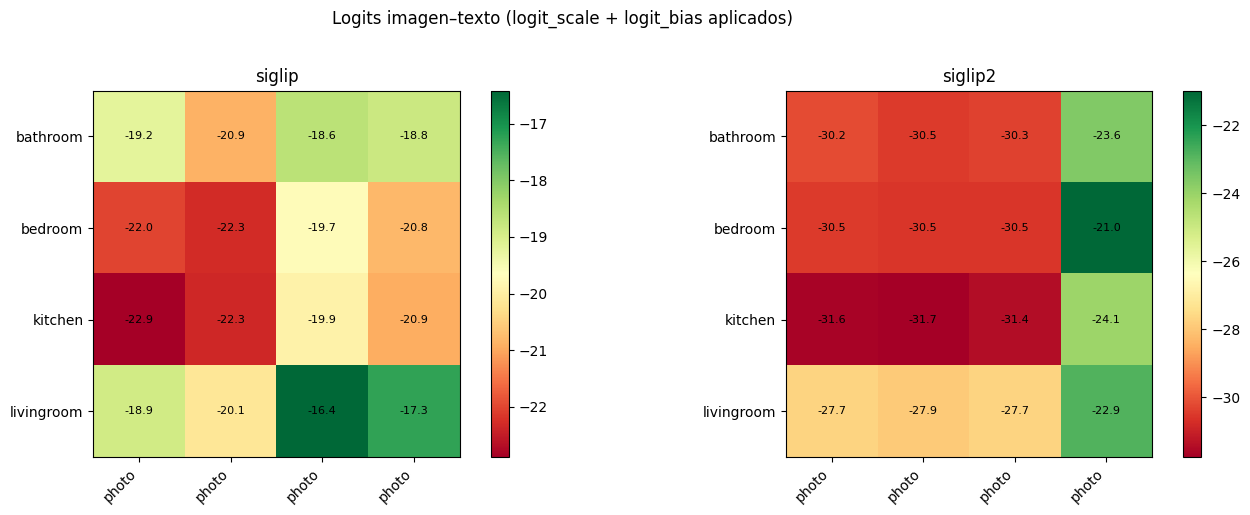

In [51]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 5))

for ax, model_name in zip(axes, MODELS):
    logits = compute_logits(model_name, scene_images, text_queries)  # (N_scenes, N_queries)

    im = ax.imshow(logits, cmap="RdYlGn")
    ax.set_xticks(range(len(text_queries)))
    ax.set_xticklabels([q.split()[3] for q in text_queries], rotation=45, ha="right")
    ax.set_yticks(range(len(scene_image_labels)))
    ax.set_yticklabels(scene_image_labels)
    ax.set_title(model_name)
    for i in range(len(scene_image_labels)):
        for j in range(len(text_queries)):
            ax.text(j, i, f"{logits[i, j]:.1f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Logits imagen–texto (logit_scale + logit_bias aplicados)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Precisión de clasificación zero-shot

Para cada imagen, el modelo asigna la query de texto con mayor similitud coseno.
Si `HAS_GROUND_TRUTH = True` se calcula accuracy real; si no, se muestran las predicciones del modelo.

In [52]:
results = {}

for model_name in MODELS:
    logits = compute_logits(model_name, scene_images, text_queries)
    preds = logits.argmax(axis=1)

    gt_indices = [scene_labels.index(lbl) for lbl in scene_image_labels]
    correct = sum(p == gt for p, gt in zip(preds, gt_indices))
    accuracy = correct / len(scene_image_labels)

    results[model_name] = {
        "logits": logits,
        "predictions": preds,
        "accuracy": accuracy,
    }

    print(f"{model_name}: {correct}/{len(scene_image_labels)} ({accuracy:.0%})")
    for img_lbl, pred in zip(scene_image_labels, preds):
        predicted_label = scene_labels[pred]
        status = "✓" if predicted_label == img_lbl else "✗"
        print(f"  {status}  {img_lbl:15s} → {predicted_label}")

siglip: 1/4 (25%)
  ✗  bathroom        → kitchen
  ✗  bedroom         → kitchen
  ✓  kitchen         → kitchen
  ✗  livingroom      → kitchen
siglip2: 1/4 (25%)
  ✗  bathroom        → livingroom
  ✗  bedroom         → livingroom
  ✗  kitchen         → livingroom
  ✓  livingroom      → livingroom


## 5. Coherencia semántica texto–texto

Se verifica si los modelos ordenan correctamente queries de navegación semánticamente similares.

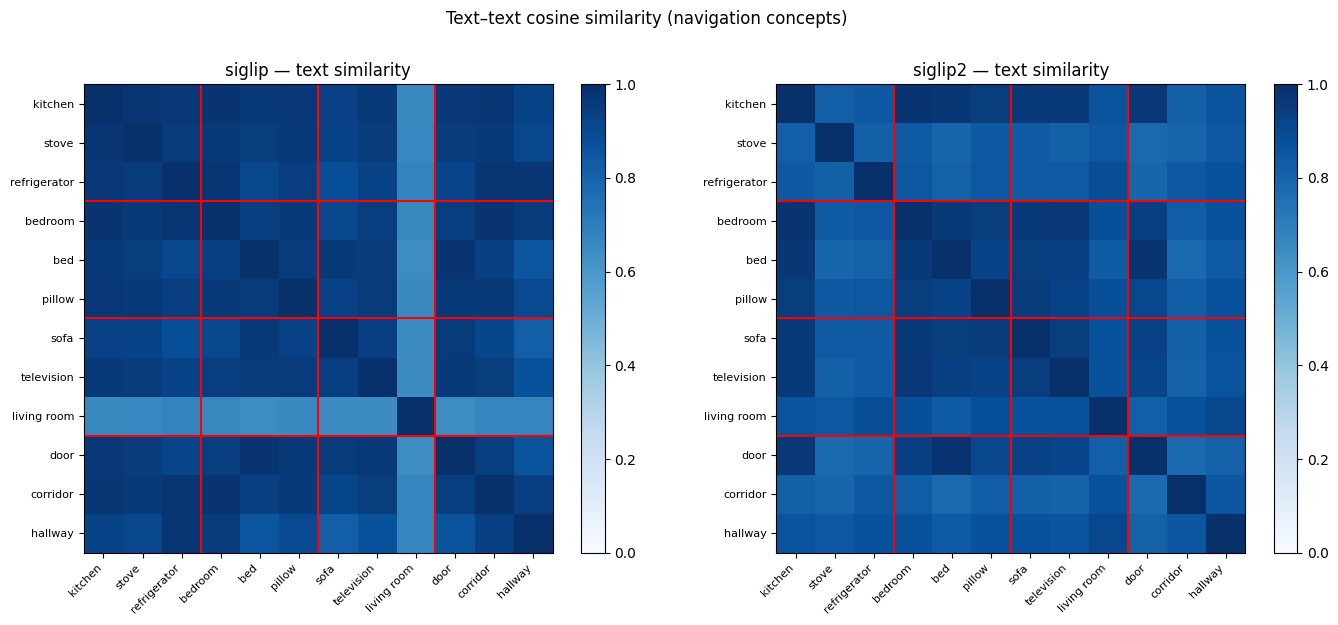

In [53]:
nav_concepts = [
    "kitchen", "stove", "refrigerator",    # cluster cocina
    "bedroom", "bed", "pillow",             # cluster dormitorio
    "sofa", "television", "living room",    # cluster sala de estar
    "door", "corridor", "hallway",          # cluster navegación
]

fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 6))

for ax, model_name in zip(axes, MODELS):
    embs = embed_text(model_name, nav_concepts)
    sim = cosine_sim(embs, embs)

    im = ax.imshow(sim, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(len(nav_concepts)))
    ax.set_xticklabels(nav_concepts, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(nav_concepts)))
    ax.set_yticklabels(nav_concepts, fontsize=8)
    ax.set_title(f"{model_name} — text similarity")
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Dibujar límites entre clusters
    for boundary in [3, 6, 9]:
        ax.axhline(boundary - 0.5, color="red", lw=1.5)
        ax.axvline(boundary - 0.5, color="red", lw=1.5)

fig.suptitle("Text–text cosine similarity (navigation concepts)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Benchmark — latencia y rendimiento

In [54]:
N_WARMUP = 5
N_RUNS = 50
BATCH_SIZES = [1, 4, 8, 16]

bench_image = make_placeholder((128, 128, 128))
bench_text = "a room inside a house"


def benchmark_fn(fn, n_warmup=N_WARMUP, n_runs=N_RUNS):
    for _ in range(n_warmup):
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return elapsed / n_runs * 1000  # ms por llamada


bench_results = {name: {"text": {}, "image": {}} for name in MODELS}

for model_name in MODELS:
    print(f"\n--- {model_name} ---")

    # Latencia de texto (query simple)
    ms = benchmark_fn(lambda: embed_text(model_name, [bench_text]))
    bench_results[model_name]["text"][1] = ms
    print(f"  text  batch=1:  {ms:.1f} ms")

    # Latencia de imagen por tamaño de batch
    for bs in BATCH_SIZES:
        imgs = [bench_image] * bs
        ms = benchmark_fn(lambda: embed_images(model_name, imgs))
        bench_results[model_name]["image"][bs] = ms
        throughput = bs / (ms / 1000)
        print(f"  image batch={bs:2d}: {ms:6.1f} ms  ({throughput:.0f} img/s)")


--- siglip ---
  text  batch=1:  7.6 ms
  image batch= 1:   17.0 ms  (59 img/s)
  image batch= 4:   52.9 ms  (76 img/s)
  image batch= 8:   92.2 ms  (87 img/s)
  image batch=16:  185.1 ms  (86 img/s)

--- siglip2 ---
  text  batch=1:  6.5 ms
  image batch= 1:   17.0 ms  (59 img/s)
  image batch= 4:   54.0 ms  (74 img/s)
  image batch= 8:   94.3 ms  (85 img/s)
  image batch=16:  182.2 ms  (88 img/s)


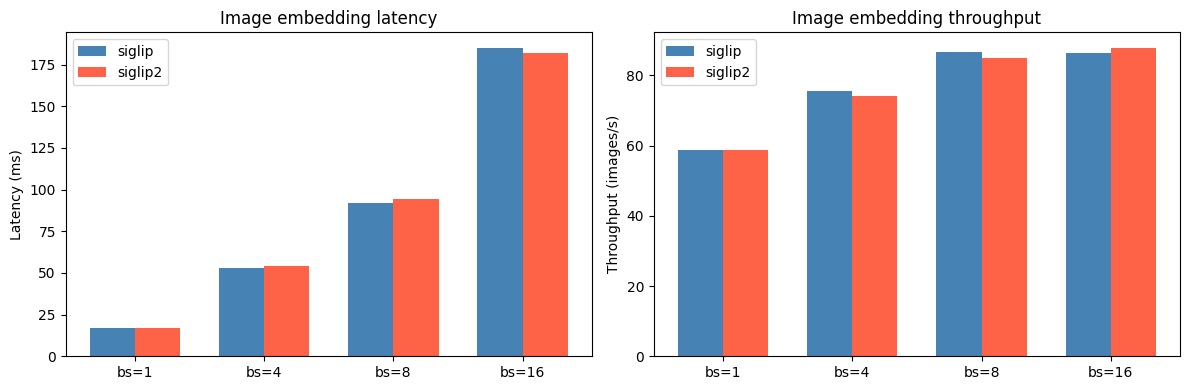

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {"siglip": "steelblue", "siglip2": "tomato"}
x = np.arange(len(BATCH_SIZES))
width = 0.35

# Latencia
ax = axes[0]
for i, model_name in enumerate(MODELS):
    latencies = [bench_results[model_name]["image"][bs] for bs in BATCH_SIZES]
    ax.bar(x + i * width, latencies, width, label=model_name, color=colors[model_name])
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"bs={bs}" for bs in BATCH_SIZES])
ax.set_ylabel("Latency (ms)")
ax.set_title("Image embedding latency")
ax.legend()

# Rendimiento
ax = axes[1]
for i, model_name in enumerate(MODELS):
    throughputs = [bs / (bench_results[model_name]["image"][bs] / 1000) for bs in BATCH_SIZES]
    ax.bar(x + i * width, throughputs, width, label=model_name, color=colors[model_name])
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"bs={bs}" for bs in BATCH_SIZES])
ax.set_ylabel("Throughput (images/s)")
ax.set_title("Image embedding throughput")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Tabla resumen

In [56]:
print(f"{'Model':<12} {'Accuracy':>10} {'Text lat (ms)':>15} {'Img lat bs=1 (ms)':>20} {'Img lat bs=8 (ms)':>20} {'Throughput bs=8 (img/s)':>25}")
print("-" * 105)

for model_name in MODELS:
    acc = results[model_name]["accuracy"]
    txt_lat = bench_results[model_name]["text"].get(1, float("nan"))
    img_lat_1 = bench_results[model_name]["image"].get(1, float("nan"))
    img_lat_8 = bench_results[model_name]["image"].get(8, float("nan"))
    tput_8 = 8 / (img_lat_8 / 1000)
    print(f"{model_name:<12} {acc:>10.0%} {txt_lat:>15.1f} {img_lat_1:>20.1f} {img_lat_8:>20.1f} {tput_8:>25.0f}")

Model          Accuracy   Text lat (ms)    Img lat bs=1 (ms)    Img lat bs=8 (ms)   Throughput bs=8 (img/s)
---------------------------------------------------------------------------------------------------------
siglip              25%             7.6                 17.0                 92.2                        87
siglip2             25%             6.5                 17.0                 94.3                        85


## 8. Espacio de embeddings — visualización PCA

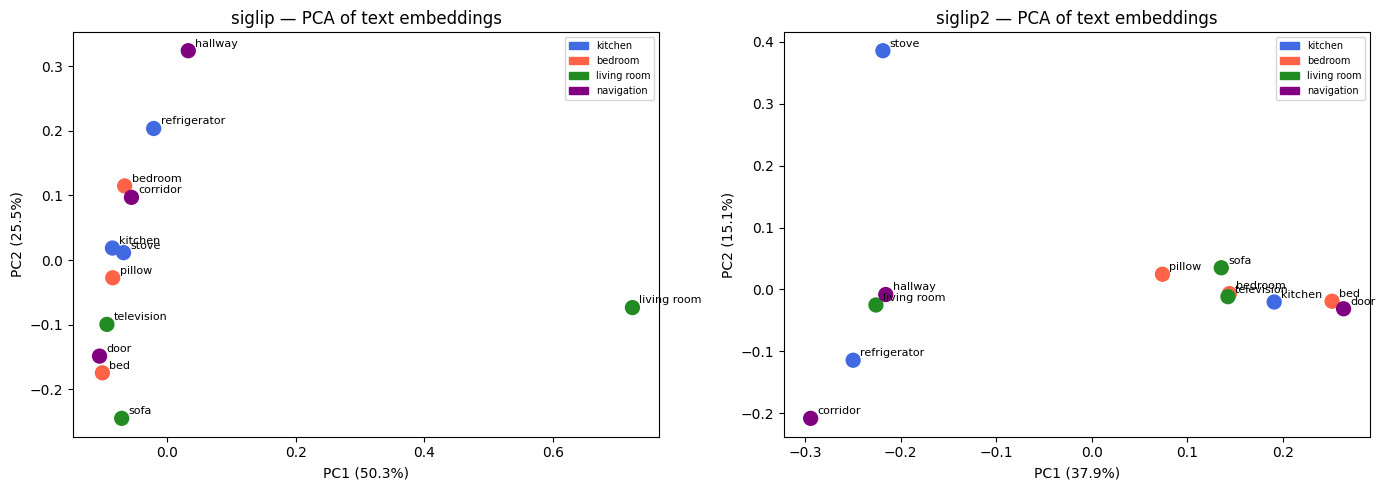

In [57]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 5))

all_concepts = nav_concepts
cluster_colours = ["royalblue"] * 3 + ["tomato"] * 3 + ["forestgreen"] * 3 + ["purple"] * 3
cluster_labels = ["kitchen", "bedroom", "living room", "navigation"]
legend_patches = [
    mpatches.Patch(color="royalblue", label="kitchen"),
    mpatches.Patch(color="tomato", label="bedroom"),
    mpatches.Patch(color="forestgreen", label="living room"),
    mpatches.Patch(color="purple", label="navigation"),
]

for ax, model_name in zip(axes, MODELS):
    embs = embed_text(model_name, all_concepts)
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embs)

    ax.scatter(coords[:, 0], coords[:, 1], c=cluster_colours, s=100, zorder=3)
    for i, concept in enumerate(all_concepts):
        ax.annotate(concept, coords[i], textcoords="offset points", xytext=(5, 3), fontsize=8)
    ax.set_title(f"{model_name} — PCA of text embeddings")
    ax.legend(handles=legend_patches, loc="best", fontsize=7)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

## 9. Benchmark con todas las imágenes locales

Ejecuta la evaluación usando las 50 imágenes por categoría en lugar de 1, para obtener métricas de accuracy más representativas.

In [58]:
full_images, full_labels = load_local_images(n=50)
print(f"Total imágenes: {len(full_images)} ({len(full_images)//len(scene_labels)} por categoría)\n")

full_results = {}

for model_name in MODELS:
    # Procesar en batches para no saturar memoria
    BATCH = 32
    all_logits = []
    for i in range(0, len(full_images), BATCH):
        batch_imgs = full_images[i:i+BATCH]
        all_logits.append(compute_logits(model_name, batch_imgs, text_queries))
    logits = np.vstack(all_logits)
    preds = logits.argmax(axis=1)

    gt_indices = [scene_labels.index(lbl) for lbl in full_labels]
    correct = sum(p == gt for p, gt in zip(preds, gt_indices))
    accuracy = correct / len(full_labels)
    full_results[model_name] = accuracy

    # Accuracy por categoría
    print(f"── {model_name}  (accuracy global: {accuracy:.0%}) ──")
    for category in scene_labels:
        idxs = [i for i, lbl in enumerate(full_labels) if lbl == category]
        cat_correct = sum(preds[i] == scene_labels.index(category) for i in idxs)
        print(f"  {category:15s}: {cat_correct}/{len(idxs)}  ({cat_correct/len(idxs):.0%})")
    print()

# Comparativa final
print("── Comparativa global ──")
for model_name, acc in full_results.items():
    bar = "█" * int(acc * 30)
    print(f"  {model_name:10s}: {bar} {acc:.1%}")

Total imágenes: 200 (50 por categoría)

── siglip  (accuracy global: 36%) ──
  bathroom       : 2/50  (4%)
  bedroom        : 2/50  (4%)
  kitchen        : 30/50  (60%)
  livingroom     : 38/50  (76%)

── siglip2  (accuracy global: 25%) ──
  bathroom       : 0/50  (0%)
  bedroom        : 0/50  (0%)
  kitchen        : 0/50  (0%)
  livingroom     : 50/50  (100%)

── Comparativa global ──
  siglip    : ██████████ 36.0%
  siglip2   : ███████ 25.0%
